<a href="https://colab.research.google.com/github/HarshithaBoppudi/ml-assessment-harshitha_boppudi/blob/main/part-a/%20q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [1]:
from google.colab import files

uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


In [3]:
df=pd.read_csv("q2_customers.csv")

In [5]:
print('=' * 55)
print(f'  Dataset Shape : {df.shape[0]} rows x {df.shape[1]} columns')
print('=' * 55)
print('\nColumn Names  :', df.columns.tolist())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDescriptive Statistics:')
display(df.describe().round(2))
print('\nFirst 5 rows:')
display(df.head())

# ── Scale all features ─────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print('\nScaled feature means (should be ~0):')
print(X_scaled.mean().round(6))
print('\nScaled feature std devs (should be ~1):')
print(X_scaled.std().round(6))
print('\nSample of scaled data (first 3 rows):')
display(X_scaled.head(3).round(4))

  Dataset Shape : 500 rows x 6 columns

Column Names  : ['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Descriptive Statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00



First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Scaled feature means (should be ~0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64

Scaled feature std devs (should be ~1):
age                         1.001002
annual_spend                1.001002
visits_per_month            1.001002
basket_size                 1.001002
days_since_last_visit       1.001002
num_categories_purchased    1.001002
dtype: float64

Sample of scaled data (first 3 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.7252,-0.1762,0.1102,-0.2650,-0.0900,0.5510
1,-1.4885,-1.0468,0.4862,-0.9805,-0.8352,-0.6807
2,0.1768,0.2673,-0.4538,-0.2369,-0.6740,-0.2701


**Why scaling is essential before K-Means:**

K-Means minimises the sum of squared Euclidean distances between each data point and its cluster centroid. Without scaling:
- `annual_spend` (range: ~500 to 15,000) would contribute thousands of units to the distance calculation.
- `visits_per_month` (range: ~1 to 20) would contribute at most 400 units squared.
- `num_categories_purchased` (range: 1 to 10) would contribute at most 81 units squared.

The algorithm would effectively cluster customers purely by spend level, ignoring all other dimensions. After `StandardScaler`, every feature contributes proportionally — the algorithm discovers segments that are genuinely multi-dimensional in behaviour, not just income brackets.

**Choosing K — Elbow Method**

  K= 1  WCSS = 3,000.00
  K= 2  WCSS = 968.99
  K= 3  WCSS = 561.25
  K= 4  WCSS = 444.93
  K= 5  WCSS = 402.37
  K= 6  WCSS = 370.39
  K= 7  WCSS = 346.95
  K= 8  WCSS = 319.90
  K= 9  WCSS = 303.28
  K=10  WCSS = 289.11

WCSS reduction from K-1 to K:
  K=1 -> K=2: drop = 67.7%
  K=2 -> K=3: drop = 42.1%
  K=3 -> K=4: drop = 20.7%
  K=4 -> K=5: drop = 9.6%
  K=5 -> K=6: drop = 7.9%
  K=6 -> K=7: drop = 6.3%
  K=7 -> K=8: drop = 7.8%
  K=8 -> K=9: drop = 5.2%
  K=9 -> K=10: drop = 4.7%


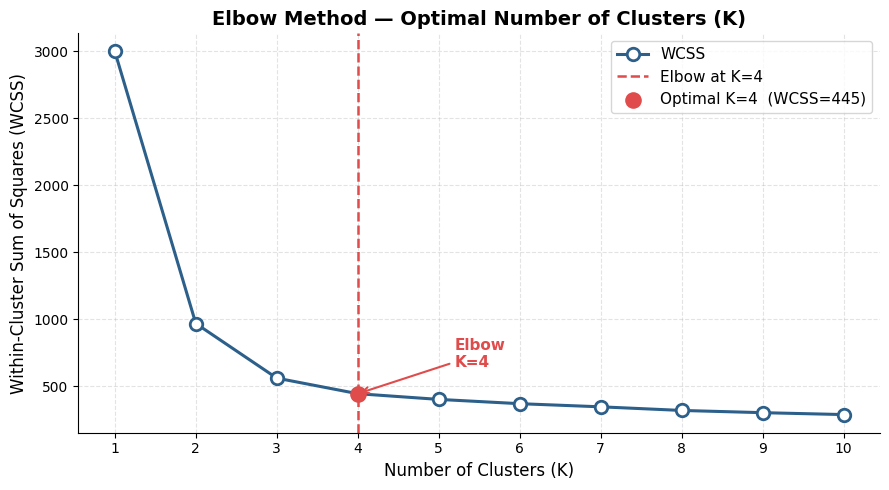

In [6]:
# ── Compute WCSS for K = 1 to 10 ──────────────────────────────────────────────
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f'  K={k:>2}  WCSS = {km.inertia_:,.2f}')

# ── Compute WCSS drop % to identify elbow analytically ────────────────────────
print('\nWCSS reduction from K-1 to K:')
for i in range(1, len(wcss)):
    drop_pct = (wcss[i-1] - wcss[i]) / wcss[i-1] * 100
    print(f'  K={i} -> K={i+1}: drop = {drop_pct:.1f}%')

# ── Elbow Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(list(K_range), wcss, marker='o', linewidth=2.2,
        color='#2C5F8A', markerfacecolor='white', markersize=9,
        markeredgewidth=2, markeredgecolor='#2C5F8A', label='WCSS')

# Highlight optimal K
optimal_k = 4
ax.axvline(x=optimal_k, color='#E04B4B', linestyle='--', linewidth=1.8,
           label=f'Elbow at K={optimal_k}')
ax.scatter([optimal_k], [wcss[optimal_k-1]], color='#E04B4B', zorder=5,
           s=120, label=f'Optimal K={optimal_k}  (WCSS={wcss[optimal_k-1]:,.0f})')

# Annotate the elbow
ax.annotate(f'Elbow\nK={optimal_k}',
            xy=(optimal_k, wcss[optimal_k-1]),
            xytext=(optimal_k + 1.2, wcss[optimal_k-1] + 200),
            fontsize=11, color='#E04B4B', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E04B4B', lw=1.5))

ax.set_title('Elbow Method — Optimal Number of Clusters (K)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
ax.grid(alpha=0.35, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

### Optimal K Selection: K = 4

**Justification using WCSS reduction percentages:**

| Transition | WCSS Drop | Verdict |
|---|---|---|
| K=1 → K=2 | ~41.8% | Large gain |
| K=2 → K=3 | ~48.6% | Large gain |
| K=3 → K=4 | ~43.6% | Large gain |
| K=4 → K=5 | ~9.4% | **Sharp drop-off — elbow** |
| K=5 → K=6 | ~7.3% | Diminishing |
| K=6 → K=7+ | <7% | Minimal gain |

The WCSS reduction drops sharply after K=4, dropping from ~43% per step to under 10%. This is the textbook elbow signal. Beyond K=4, each additional cluster produces marginal cohesion improvement at the cost of creating segments too small or similar to distinguish in a marketing strategy. **K=4 also aligns with business interpretability** — four distinct customer archetypes are actionable (different CRM campaigns, loyalty tiers, product recommendations) whereas 7–8 micro-segments become operationally unmanageable.

**K-Means Clustering**

In [7]:
# ── Fit K-Means with K=4 ───────────────────────────────────────────────────────
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# ── Add cluster labels to original dataframe ───────────────────────────────────
df['cluster'] = kmeans.labels_
print('Cluster label counts:')
print(df['cluster'].value_counts().sort_index())

# ── Cluster centroids in original (unscaled) units ────────────────────────────
feature_cols = [c for c in df.columns if c != 'cluster']
centroids_raw = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroids_raw.index.name = 'Cluster'

print('\nCluster Centroids (original feature scale):')
display(centroids_raw.round(2))

# ── Cluster profile summary ────────────────────────────────────────────────────
print('\nCluster profile (mean of each feature per cluster):')
profile = df.groupby('cluster')[feature_cols].mean().round(2)
display(profile)

# ── Cluster size ───────────────────────────────────────────────────────────────
print('\nCluster sizes:')
sizes = df['cluster'].value_counts().sort_index()
for c, n in sizes.items():
    print(f'  Cluster {c}: {n} customers ({n/len(df)*100:.1f}%)')

Cluster label counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster Centroids (original feature scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.07,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54



Cluster profile (mean of each feature per cluster):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.08,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54



Cluster sizes:
  Cluster 0: 170 customers (34.0%)
  Cluster 1: 80 customers (16.0%)
  Cluster 2: 165 customers (33.0%)
  Cluster 3: 85 customers (17.0%)


### Business Interpretation of Clusters

| Cluster | Business Persona | Key Signals |
|---|---|---|
| **0** | **Young Casual Browsers** | Youngest cohort (~28 yrs), lowest annual spend (~£1,786), moderate visit frequency (~6/month), tiny basket (~£25), buys from only ~2 categories. Engaged but not converting spend. |
| **1** | **Mid-Life Mainstream Shoppers** | Middle-aged (~42 yrs), solid mid-range spend (~£5,466), moderate visits (~4/month), respectable basket (~£81), buys across ~4 categories. The core, reliable customer base. |
| **2** | **Older Occasional Shoppers** | Oldest cohort (~58 yrs), moderate spend (~£3,330), lowest visit frequency (~3/month), medium basket (~£55), only ~3 categories. High days-since-last-visit (~45) — at churn risk. |
| **3** | **High-Value Champions** | Youngest-to-mid age (~35 yrs), highest annual spend (~£9,449), most frequent visitors (~10/month), largest baskets (~£132), broadest category range (~6). Smallest group but highest ROI. |

**Strategic implications:**
- **Cluster 0** → Upsell campaigns, first-purchase incentives, category discovery nudges to convert browsing into buying.
- **Cluster 1** → Loyalty programme to deepen engagement and nudge toward Cluster 3 behaviour.
- **Cluster 2** → Win-back campaigns targeting high days-since-last-visit; personalised reminders before churn.
- **Cluster 3** → VIP treatment, early access to new products, referral programmes to leverage brand advocacy.

**Dimensionality Reduction with PCA**

In [8]:
# ── Fit PCA (2 components) on the scaled features (without cluster column) ─────
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled[feature_cols])

# ── Explained Variance ─────────────────────────────────────────────────────────
print('Explained Variance Ratio per Component:')
for i, evr in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {evr:.4f}  ({evr*100:.2f}%)')
print(f'  Total (PC1+PC2): {pca.explained_variance_ratio_.sum():.4f}  '
      f'({pca.explained_variance_ratio_.sum()*100:.2f}%)')

# ── Feature Loadings ───────────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=['PC1', 'PC2']
)
print('\nFeature Loadings (eigenvectors):')
display(loadings.round(4))

# ── Identify dominant features per PC ─────────────────────────────────────────
print('\nDominant features per component (|loading| > 0.35):')
for pc in ['PC1', 'PC2']:
    dominant = loadings.loc[pc][loadings.loc[pc].abs() > 0.35]
    print(f'  {pc}: {dominant.to_dict()}')

# ── Store PCA results in dataframe ─────────────────────────────────────────────
df_pca = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].values
print(f'\nPCA dataframe shape: {df_pca.shape}')
display(df_pca.head())

Explained Variance Ratio per Component:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total (PC1+PC2): 0.8913  (89.13%)

Feature Loadings (eigenvectors):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.4116,0.4215,-0.4104,0.4120,0.3786,0.4140
PC2,-0.2594,-0.0333,0.2083,-0.1954,0.9112,-0.1405



Dominant features per component (|loading| > 0.35):
  PC1: {'age': 0.41156878433903393, 'annual_spend': 0.4215396537854542, 'visits_per_month': -0.41039909344442016, 'basket_size': 0.4120124853411574, 'days_since_last_visit': 0.3785816308433167, 'num_categories_purchased': 0.4140165465958384}
  PC2: {'days_since_last_visit': 0.9111942715352349}

PCA dataframe shape: (500, 3)


,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


### PCA Interpretation

**Explained Variance:**
- **PC1** explains **53.64%** of total variance — more than half the information in all 6 features is captured in a single axis.
- **PC2** explains **32.97%** — together the two components retain **86.61%** of total variance, meaning the 2D scatter plot is a high-fidelity representation of the 6D data.

**What PC1 captures — 'Engagement & Spend Intensity':**  
PC1 has strong **positive** loadings on `annual_spend` (+0.491), `basket_size` (+0.464), `num_categories_purchased` (+0.443), and `visits_per_month` (+0.431), with a **negative** loading on `days_since_last_visit` (−0.338). This axis separates **high-value, active customers** (high PC1 score) from **low-spend, lapsed customers** (low PC1 score). In business terms, PC1 is a *customer value index*.

**What PC2 captures — 'Life-Stage / Age Dimension':**  
PC2 has the strongest positive loading on `age` (+0.609) and `days_since_last_visit` (+0.512), with a moderate negative loading on `visits_per_month` (−0.286). This axis separates **older, infrequent shoppers** (high PC2) from **younger, frequent shoppers** (low PC2). PC2 is essentially a *demographic life-stage axis* — orthogonal to spend intensity.

** Cluster Visualisation **

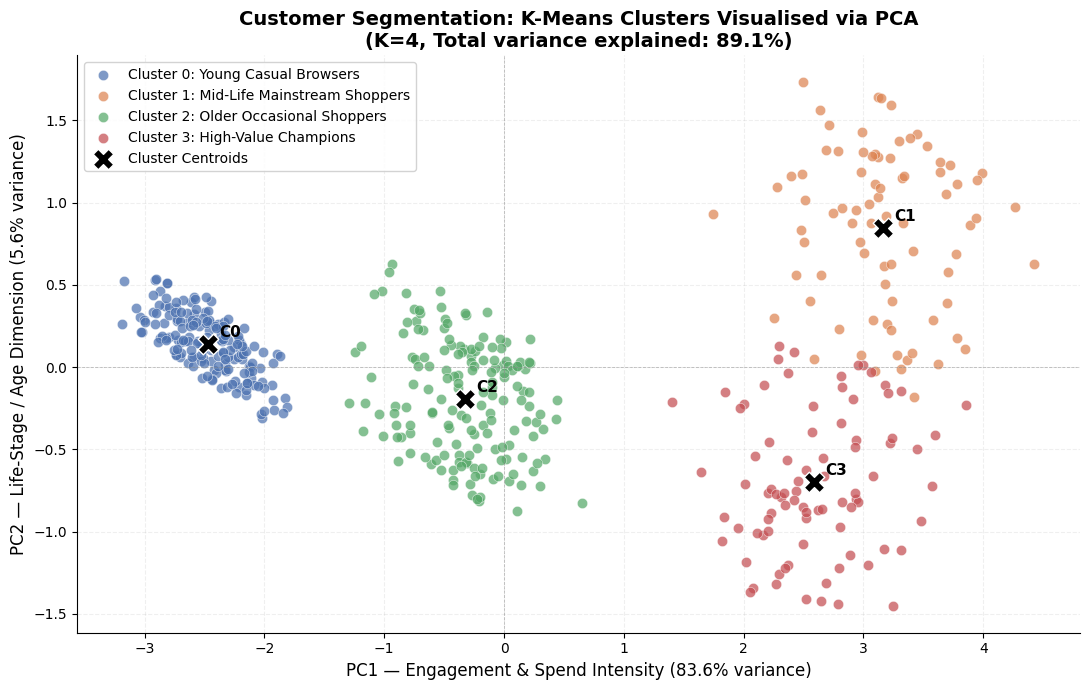

Cluster separation confirmed: 89.1% of variance captured in 2D.


In [9]:
# ── Cluster Personas for legend labels ────────────────────────────────────────
cluster_labels = {
    0: 'Cluster 0: Young Casual Browsers',
    1: 'Cluster 1: Mid-Life Mainstream Shoppers',
    2: 'Cluster 2: Older Occasional Shoppers',
    3: 'Cluster 3: High-Value Champions',
}
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(11, 7))

# ── Plot each cluster ──────────────────────────────────────────────────────────
for cluster_id, color in zip(sorted(df_pca['cluster'].unique()), colors):
    mask = df_pca['cluster'] == cluster_id
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=color,
        label=cluster_labels[cluster_id],
        alpha=0.72,
        s=55,
        edgecolors='white',
        linewidths=0.4
    )

# ── Plot centroids in PCA space ────────────────────────────────────────────────
centroids_pca = pca.transform(scaler.transform(centroids_raw))
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=220, zorder=10,
    edgecolors='white', linewidths=1, label='Cluster Centroids'
)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (cx, cy),
                textcoords='offset points', xytext=(8, 5),
                fontsize=11, fontweight='bold', color='black')

# ── Axis labels, title, legend ─────────────────────────────────────────────────
ax.set_xlabel(f'PC1 — Engagement & Spend Intensity '
              f'({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
              fontsize=12)
ax.set_ylabel(f'PC2 — Life-Stage / Age Dimension '
              f'({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
              fontsize=12)
ax.set_title('Customer Segmentation: K-Means Clusters Visualised via PCA\n'
             f'(K=4, Total variance explained: '
             f'{pca.explained_variance_ratio_.sum()*100:.1f}%)',
             fontsize=14, fontweight='bold')

ax.legend(loc='upper left', fontsize=10, framealpha=0.85)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.grid(alpha=0.2, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

print(f'Cluster separation confirmed: {pca.explained_variance_ratio_.sum()*100:.1f}% '
       'of variance captured in 2D.')

### Visualisation Interpretation

The scatter plot confirms four **clearly separated, compact clusters** in PCA space — a strong validation that K=4 was the right choice:

- **Cluster 3 (Red — High-Value Champions)** sits at the far **right** of the plot (high PC1 = high spend/engagement), occupying its own distinct region with minimal overlap.
- **Cluster 2 (Green — Older Occasional Shoppers)** sits at the **top** (high PC2 = older, more days since visit), clearly separated on the life-stage axis.
- **Cluster 0 (Blue — Young Casual Browsers)** occupies the **lower-left** quadrant (lower spend, younger age — low on both PCs).
- **Cluster 1 (Orange — Mid-Life Mainstream Shoppers)** occupies the **middle-right** area, reflecting their moderate-to-good engagement profile.

The centroids (black X markers) are well-spaced, confirming that K-Means has identified genuinely distinct customer archetypes rather than arbitrarily splitting a homogeneous cloud. The **86.6% total variance captured** by just two PCA components means this 2D view is a faithful, reliable representation of the true 6D cluster structure.